# Air Travel Rescue Agent — Structured Development Notebook

This is the cleaned development notebook for the Week 3 **Air Travel Rescue Agent**.

### Final architecture

```text
Traveler request
      ↓
Intake Agent (GPT-OSS-120B)
      ↓
Triage Agent (GPT-OSS-120B)
      ↓
Flight tool layer
  • verify flight
  • search alternatives
  • deterministic constraint checks
  • retry handling
      ↓
Recovery Agent (deterministic structured recovery)
      ↓
Planner Agent (GPT-OSS-120B)
      ↓
Booking validation
      ↓
LangGraph HITL interrupt
      ↓
Rebooking write tool
      ↓
Resolution check
      ↓
QA Agent (GPT-OSS-120B)

Failure paths
  • transient tool failure → retry → continue
  • persistent tool failure → retry exhaustion → escalation
  • no viable flight → escalation
  • escalation → QA
```

### How to use this notebook

Run it **top-to-bottom in a fresh kernel**.  
Do not redefine graph nodes or routing functions inline while running the normal workflow.

This notebook assumes the cleaned repo structure is present under `src/`.

## 1. Environment and project setup

This section establishes the project root, loads `.env`, and checks that the cleaned repo files are present.

In [1]:
from pathlib import Path
import os
import sys
import json
import uuid

from dotenv import load_dotenv

# Notebook is expected to live in <project>/notebooks/
PROJECT_ROOT = Path("..").resolve()

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(
        f"Could not find src/ under {PROJECT_ROOT}. "
        "Open this notebook from the project's notebooks/ directory."
    )

sys.path.insert(0, str(PROJECT_ROOT))
load_dotenv(PROJECT_ROOT / ".env")

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/rohitk/mastering_agentic_ai/mastering_agentic_ai_projects/Week_3/air-travel-rescue-agent


In [2]:
required_files = [
    "src/models/schemas.py",
    "src/tools/flight_tools.py",
    "src/tools/booking_tools.py",
    "src/agents/intake.py",
    "src/agents/triage.py",
    "src/agents/recovery.py",
    "src/agents/planner.py",
    "src/agents/escalation.py",
    "src/agents/qa.py",
    "src/graph/state.py",
    "src/graph/nodes.py",
    "src/graph/routing.py",
    "src/graph/workflow.py",
    "data/flights.json",
    "data/bookings.json",
]

missing = [
    rel for rel in required_files
    if not (PROJECT_ROOT / rel).exists()
]

if missing:
    raise FileNotFoundError(
        "The cleaned project structure is incomplete. Missing:\n- "
        + "\n- ".join(missing)
    )

print("Repo structure check: PASS")

Repo structure check: PASS


## 2. Deterministic airline tool layer

Before involving an LLM, verify that flight lookup, search, feasibility filtering, and ranking behave deterministically.

**Design rule:** Python handles arithmetic, timestamp comparisons, seat availability, budget checks, and routing. The LLM should not be asked to calculate facts Python can determine exactly.

In [3]:
from src.tools.flight_tools import (
    get_flight_status,
    search_flights,
    evaluate_flight_options,
    rank_flight_options,
)
from src.tools.booking_tools import (
    get_booking_details,
    rebook_flight,
)

status = get_flight_status("UA900")
print("UA900 lookup success:", status.success)
print("UA900 status:", status.data["status"] if status.success else status.error_message)

UA900 lookup success: True
UA900 status: cancelled


In [4]:
search_result = search_flights("SFO", "LAS")

print("Search success:", search_result.success)
print("Alternatives returned:", len(search_result.data or []))

for flight in (search_result.data or [])[:8]:
    print(
        flight["flight_number"],
        "|", flight["airline"],
        "| arrival:", flight["arrival_time"],
        "| stops:", flight["stops"],
        "| extra:", flight["fare_difference"],
    )

Search success: True
Alternatives returned: 12
UA100 | United | arrival: 2026-08-27T09:55:00 | stops: 0 | extra: 275
B6101 | JetBlue | arrival: 2026-08-27T13:01:00 | stops: 0 | extra: 180
AS102 | Alaska | arrival: 2026-08-27T09:06:00 | stops: 0 | extra: 50
WN103 | Southwest | arrival: 2026-08-27T16:06:00 | stops: 0 | extra: 50
AA171 | American | arrival: 2026-08-28T20:53:00 | stops: 0 | extra: 65
WN172 | Southwest | arrival: 2026-08-28T18:45:00 | stops: 0 | extra: 50
UA250 | United | arrival: 2026-08-29T18:58:00 | stops: 1 | extra: 110
B6251 | JetBlue | arrival: 2026-08-29T13:43:00 | stops: 0 | extra: 275


In [5]:
evaluated_options = evaluate_flight_options(
    search_result.data,
    arrival_deadline="2026-08-28T11:00:00",
    max_extra_cost=100,
)

ranked_options = rank_flight_options(evaluated_options)

print("Viable options:", len(ranked_options))
for option in ranked_options:
    f = option["flight"]
    print(
        f["flight_number"],
        "| feasible:", option["feasible"],
        "| stops:", f["stops"],
        "| extra:", f["fare_difference"],
        "| arrival:", f["arrival_time"],
    )

Viable options: 4
AS102 | feasible: True | stops: 0 | extra: 50 | arrival: 2026-08-27T09:06:00
WN103 | feasible: True | stops: 0 | extra: 50 | arrival: 2026-08-27T16:06:00
UA901 | feasible: True | stops: 0 | extra: 85 | arrival: 2026-08-27T22:42:00
AA903 | feasible: True | stops: 1 | extra: 60 | arrival: 2026-08-28T10:15:00


## 3. Initialize GPT-OSS-120B through Nebius

Expected `.env` variables:

```env
NEBIUS_API_KEY=...
MODEL_BASE_URL=https://api.tokenfactory.nebius.com/v1/
MODEL_NAME=<exact GPT-OSS-120B model id from Nebius>
```

The API key is never printed.

In [6]:
from langchain_openai import ChatOpenAI

NEBIUS_API_KEY = os.getenv("NEBIUS_API_KEY")
MODEL_BASE_URL = os.getenv("MODEL_BASE_URL")
MODEL_NAME = os.getenv("MODEL_NAME")

assert NEBIUS_API_KEY, "NEBIUS_API_KEY is missing from .env"
assert MODEL_BASE_URL, "MODEL_BASE_URL is missing from .env"
assert MODEL_NAME, "MODEL_NAME is missing from .env"

llm = ChatOpenAI(
    model=MODEL_NAME,
    api_key=NEBIUS_API_KEY,
    base_url=MODEL_BASE_URL,
    temperature=0,
    max_tokens=10000,
)

print("Model:", MODEL_NAME)
print("Base URL:", MODEL_BASE_URL)
print("Nebius key loaded:", bool(NEBIUS_API_KEY))

/Users/rohitk/mastering_agentic_ai/mastering_agentic_ai_projects/Langchain Basics/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model: openai/gpt-oss-120b
Base URL: https://api.tokenfactory.nebius.com/v1/
Nebius key loaded: True


In [7]:
response = llm.invoke("Reply with exactly: Air Travel Rescue Agent ready.")
print(response.content)

Air Travel Rescue Agent ready.


## 4. Build the specialized agent chains

The project uses the same underlying GPT-OSS-120B model for several specialized roles.  
Specialization comes from the **prompt, input/output schema, permissions, and graph position**—not from using a different model for every agent.

In [8]:
from langchain_core.prompts import ChatPromptTemplate

from src.models.schemas import (
    IntakeOutput,
    TriageOutput,
    PlannerOutput,
    EscalationOutput,
    QAOutput,
    ApprovalStatus,
    ResolutionStatus,
)

### 4.1 Intake Agent

In [9]:
intake_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        '''
You are the Intake Agent for an Air Travel Rescue system.

Your ONLY job is to extract traveler and disruption information.

Do not recommend flights.
Do not solve the disruption.
Do not make booking decisions.
Do not invent missing information.

Extract:
- origin airport
- destination airport
- flight number
- travel date
- booking ID
- concise issue description
- arrival deadline
- maximum acceptable extra cost
- traveler preferences
- missing information

Rules:
1. Normalize unambiguous airport locations to IATA codes.
2. If a value is not provided and cannot safely be inferred, return null.
3. Put information required to continue in missing_information.
4. Use ISO-8601 dates/times when enough information is available.
5. Never fabricate flight numbers, booking IDs, dates, or constraints.
'''
    ),
    ("human", "{traveler_message}"),
])

intake_chain = intake_prompt | llm.with_structured_output(IntakeOutput)

### 4.2 Triage Agent

In [10]:
triage_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        '''
You are the Triage Agent for an Air Travel Rescue system.

Classify the disruption and determine whether recovery is required.

Supported disruption types:
- cancelled
- delayed
- missed_connection
- schedule_change
- unsupported

Severity:
- low
- medium
- high
- critical

Rules:
1. Cancelled flights normally require recovery and alternative search.
2. A delay requires recovery when it threatens a deadline or connection.
3. Use missed_connection when an inbound disruption makes the onward connection infeasible.
4. Use unsupported for issues outside flight recovery such as refund disputes,
   baggage claims, immigration questions, or unrelated requests.
5. Do not search flights.
6. Do not recommend an option.
7. Do not invent facts.
'''
    ),
    (
        "human",
        '''
Origin: {origin}
Destination: {destination}
Flight number: {flight_number}
Travel date: {travel_date}
Issue: {issue_description}
Arrival deadline: {arrival_deadline}
Maximum extra cost: {max_extra_cost}
Preferences: {preferences}
'''
    ),
])

triage_chain = triage_prompt | llm.with_structured_output(TriageOutput)

### 4.3 Recovery Planner Agent

In [11]:
planner_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        '''
You are the Recovery Planner Agent for an Air Travel Rescue system.

Choose the best option ONLY from the viable ranked flights provided.

Do not invent flights.
Do not select a flight outside the supplied options.
Do not recalculate deterministic feasibility.
Do not perform booking actions.

Consider:
- arrival deadline
- traveler preferences
- number of stops
- additional cost
- departure time
- arrival time
- convenience

Rules:
1. Respect all hard traveler constraints.
2. Prefer nonstop when other factors are reasonably similar.
3. Prefer lower cost when it does not materially worsen the itinerary.
4. Prefer earlier arrival when urgency matters.
5. Any rebooking requires explicit traveler approval.
6. Provide concise decision factors, not hidden chain-of-thought.
'''
    ),
    (
        "human",
        '''
Origin: {origin}
Destination: {destination}
Arrival deadline: {arrival_deadline}
Maximum extra cost: {max_extra_cost}
Preferences: {preferences}

Viable ranked flight options:
{ranked_options}
'''
    ),
])

planner_chain = planner_prompt | llm.with_structured_output(PlannerOutput)

### 4.4 Escalation Agent

In [12]:
escalation_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        '''
You are the Escalation Agent for an Air Travel Rescue system.

Prepare a concise structured handoff to a human travel-support agent when
automated recovery cannot safely complete the task.

Valid reasons:
- no_viable_flight
- tool_failure
- unsupported_request
- policy_restriction
- user_requested_human
- other

Rules:
1. Repeated flight-inventory errors should be tool_failure.
2. If search succeeds but no option satisfies constraints, use no_viable_flight.
3. Do not invent attempted actions.
4. Summarize what automation already tried so the human does not repeat work.
5. Provide one concrete recommended human action.
6. Do not modify a booking.
'''
    ),
    (
        "human",
        '''
Issue: {issue_description}
Disruption: {disruption_type}
Severity: {severity}
Route: {origin} -> {destination}
Original flight: {original_flight}
Last error: {last_error}
Retry count: {retry_count}
Viable ranked options: {ranked_options}
Actions attempted: {action_history}
'''
    ),
])

escalation_chain = escalation_prompt | llm.with_structured_output(EscalationOutput)

### 4.5 QA Agent

In [13]:
qa_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        '''
You are the QA Agent for an Air Travel Rescue system.

Review the completed interaction.

Evaluate:
- correct disruption classification
- whether traveler constraints were respected
- whether appropriate tools were used
- whether approval was obtained before write actions
- whether unsupported actions were attempted
- unnecessary tool calls
- whether the issue was resolved or escalated appropriately
- whether follow-up is required

Do not change the booking.
Do not recommend new flights.
Do not invent events absent from the workflow state.
'''
    ),
    (
        "human",
        '''
Issue description: {issue_description}
Disruption type: {disruption_type}
Arrival deadline: {arrival_deadline}
Maximum extra cost: {max_extra_cost}
Preferences: {preferences}
Original flight: {original_flight}
Recommended plan: {recommended_plan}
Approval status: {approval_status}
Booking updated: {booking_updated}
Resolution status: {resolution_status}
Resolution summary: {resolution_summary}
Action history: {action_history}
Escalation: {escalation_output}
'''
    ),
])

qa_chain = qa_prompt | llm.with_structured_output(QAOutput)

## 5. Agent smoke tests

These tests validate the LLM contracts independently before we put everything inside LangGraph.

In [14]:
test_message = '''
My United flight UA900 from SFO to Las Vegas was cancelled.
My booking ID is BR1001.
I'm traveling on August 27, 2026.
I need to arrive before 11 AM on August 28.
I can spend up to $100 extra and prefer nonstop.
'''

intake_result = intake_chain.invoke({"traveler_message": test_message})
intake_result

IntakeOutput(origin='SFO', destination='LAS', flight_number='UA900', travel_date='2026-08-27', booking_id='BR1001', issue_description='flight cancelled', arrival_deadline='2026-08-28T11:00:00', max_extra_cost=100.0, preferences=['nonstop'], missing_information=[])

In [15]:
triage_result = triage_chain.invoke({
    "origin": intake_result.origin,
    "destination": intake_result.destination,
    "flight_number": intake_result.flight_number,
    "travel_date": intake_result.travel_date,
    "issue_description": intake_result.issue_description,
    "arrival_deadline": intake_result.arrival_deadline,
    "max_extra_cost": intake_result.max_extra_cost,
    "preferences": intake_result.preferences,
})

triage_result

TriageOutput(disruption_type=<DisruptionType.CANCELLED: 'cancelled'>, severity=<Severity.HIGH: 'high'>, recovery_required=True, search_alternatives=False, urgency_reason='Arrival deadline may be missed due to cancellation', unsupported_reason=None)

In [16]:
planner_input = []

for option in ranked_options:
    f = option["flight"]
    planner_input.append({
        "flight_number": f["flight_number"],
        "airline": f["airline"],
        "origin": f["origin"],
        "destination": f["destination"],
        "departure_time": f["departure_time"],
        "arrival_time": f["arrival_time"],
        "stops": f["stops"],
        "fare_difference": f["fare_difference"],
        "available_seats": f["available_seats"],
    })

planner_result = planner_chain.invoke({
    "origin": "SFO",
    "destination": "LAS",
    "arrival_deadline": "2026-08-28T11:00:00",
    "max_extra_cost": 100,
    "preferences": ["nonstop"],
    "ranked_options": planner_input,
})

valid_flights = {x["flight"]["flight_number"] for x in ranked_options}

if planner_result.plan_available and planner_result.recommended_plan:
    assert (
        planner_result.recommended_plan.recommended_flight_number
        in valid_flights
    ), "Planner selected a flight outside the deterministic viable set."

planner_result

PlannerOutput(plan_available=True, recommended_plan=RecoveryPlan(recommended_flight_number='AS102', decision_factors=[PlanDecisionFactor(factor='Nonstop', assessment='Meets preferred nonstop'), PlanDecisionFactor(factor='Arrival before deadline', assessment='Arrives 2026-08-27T09:06, well before 2026-08-28T11:00'), PlanDecisionFactor(factor='Cost', assessment='Fare difference $50 ≤ $100 max extra'), PlanDecisionFactor(factor='Earliest arrival', assessment='Earliest arrival among nonstop options'), PlanDecisionFactor(factor='Seat availability', assessment='6 seats available')], estimated_extra_cost=50.0, requires_booking_change=False, requires_user_approval=False, confidence=0.97), alternatives_considered=['WN103 – later arrival (16:06) same cost', 'UA901 – later arrival (22:42) higher cost', 'AA903 – 1 stop, less preferred'], no_plan_reason=None)

## 6. Build the final LangGraph once

The graph implementation is centralized in `src/graph/workflow.py`.

This is intentional: the notebook should **exercise the application**, not contain multiple stale copies of routing and graph-building logic.

In [17]:
from src.graph.workflow import build_graph

graph = build_graph(
    intake_chain=intake_chain,
    triage_chain=triage_chain,
    planner_chain=planner_chain,
    escalation_chain=escalation_chain,
    qa_chain=qa_chain,
)

print("Graph compiled successfully.")

Graph compiled successfully.


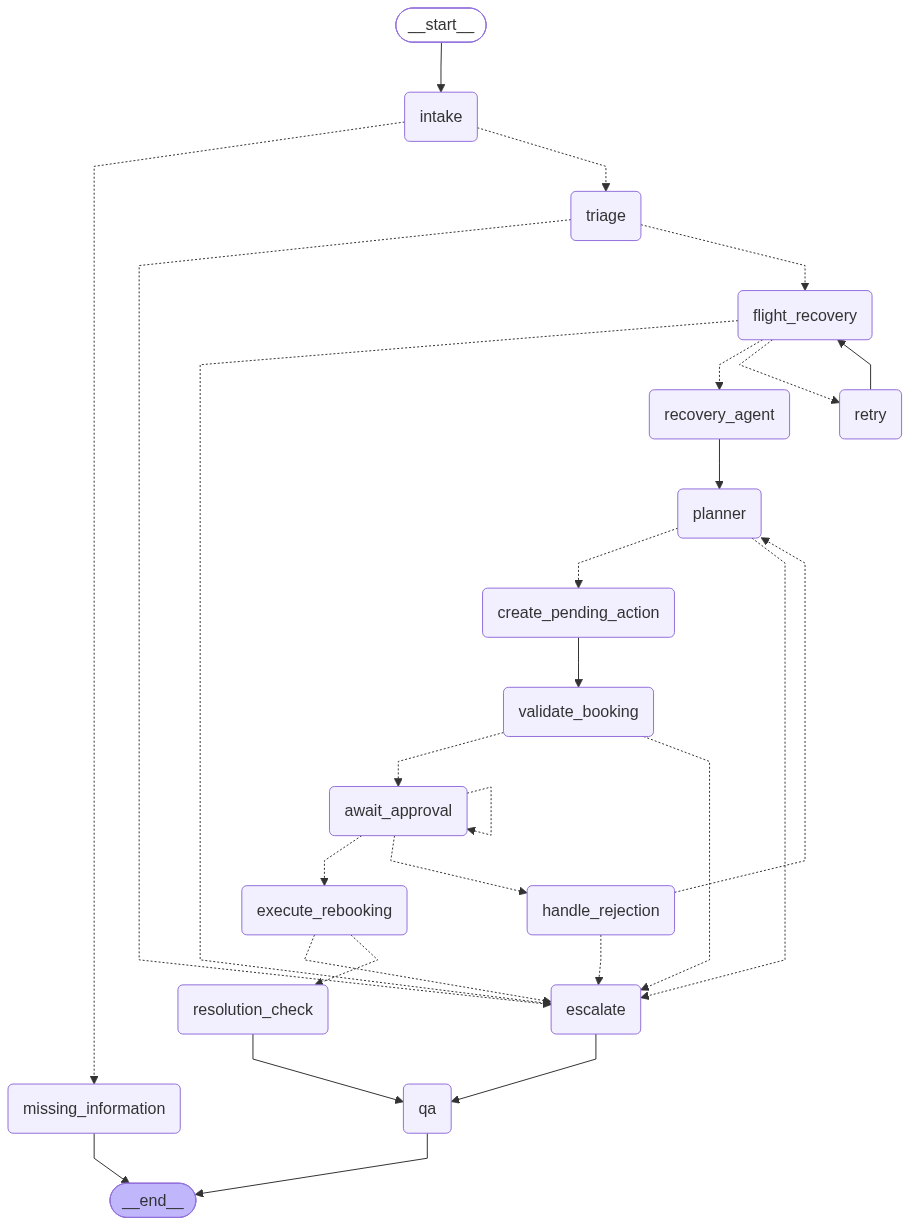

In [18]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # Mermaid PNG rendering can depend on the environment.
    print(graph.get_graph().draw_mermaid())

## 7. Scenario helpers

Each scenario receives a **new LangGraph thread ID** so checkpoints from an earlier run cannot leak into a later test.

The demo booking reset keeps repeated notebook runs deterministic.

In [19]:
from langchain_core.messages import HumanMessage
from langgraph.types import Command


def new_config(prefix: str):
    return {
        "configurable": {
            "thread_id": f"{prefix}-{uuid.uuid4().hex[:8]}"
        }
    }


def reset_demo_booking():
    bookings_path = PROJECT_ROOT / "data" / "bookings.json"

    with open(bookings_path, "r", encoding="utf-8") as f:
        bookings = json.load(f)

    found = False
    for booking in bookings:
        if booking.get("booking_id") == "BR1001":
            booking["flight_number"] = "UA900"
            booking["origin"] = "SFO"
            booking["destination"] = "LAS"
            booking["travel_date"] = "2026-08-27"
            booking["status"] = "disrupted"
            found = True
            break

    if not found:
        raise ValueError("Demo booking BR1001 was not found.")

    with open(bookings_path, "w", encoding="utf-8") as f:
        json.dump(bookings, f, indent=2)


def show_result_summary(result):
    print("Disruption:", result.get("disruption_type"))
    print("Retry count:", result.get("retry_count"))
    print("Last error:", result.get("last_error"))
    print("Recommended plan:", result.get("recommended_plan"))
    print("Approval:", result.get("approval_status"))
    print("Booking updated:", result.get("booking_updated"))
    print("Resolution:", result.get("resolution_status"))
    print("Escalation:", result.get("escalation_output"))
    print("QA:", result.get("qa_review"))


def show_action_history(result):
    for record in result.get("action_history", []):
        print(
            record.action,
            "|", record.tool,
            "| success:", record.success,
            "|", record.details,
        )

## 8. Scenario 1 — Happy path with real HITL

Expected flow:

```text
cancelled flight
→ search alternatives
→ planner recommendation
→ LangGraph interrupt
→ traveler approves
→ rebook
→ resolved
→ QA
```

In [20]:
reset_demo_booking()

happy_state = {
    "messages": [
        HumanMessage(content='''
My United flight UA900 from SFO to Las Vegas was cancelled.
My booking ID is BR1001.
I'm traveling on August 27, 2026.
I need to arrive before 11 AM on August 28.
I can spend up to $100 extra and prefer nonstop.
''')
    ],
    "approval_status": ApprovalStatus.PENDING,
    "retry_count": 0,
    "simulate_search_failure": False,
    "simulate_persistent_search_failure": False,
}

happy_config = new_config("happy")

happy_interrupt = graph.invoke(
    happy_state,
    config=happy_config,
)

print("Interrupt:", happy_interrupt.get("__interrupt__"))
print("Recommended:", happy_interrupt.get("recommended_plan"))

Interrupt: [Interrupt(value={'type': 'approval_required', 'message': 'Rebook onto AS102 for an additional $50.00?', 'flight_number': 'AS102', 'additional_cost': 50.0}, id='b115acee5592a985fb185f8cd5a9566b')]
Recommended: recommended_flight_number='AS102' decision_factors=[PlanDecisionFactor(factor='Nonstop', assessment='Meets preference'), PlanDecisionFactor(factor='Arrival before deadline', assessment='Arrives 2026-08-27T09:06, well before 11:00 deadline'), PlanDecisionFactor(factor='Cost', assessment='Fare difference $50, well within $100 limit'), PlanDecisionFactor(factor='Departure/Arrival time', assessment='Earliest departure (06:10) and earliest arrival among nonstop options'), PlanDecisionFactor(factor='Seat availability', assessment='6 seats available')] estimated_extra_cost=50.0 requires_booking_change=False requires_user_approval=False confidence=0.99


In [21]:
print("=== HAPPY PATH DIAGNOSTIC ===")

fields = [
    "origin",
    "destination",
    "flight_number",
    "booking_id",
    "missing_information",
    "disruption_type",
    "recovery_required",
    "search_alternatives",
    "last_error",
    "retry_count",
    "ranked_options",
    "recovery_output",
    "planner_output",
    "recommended_plan",
    "pending_action",
    "approval_status",
    "escalation_required",
    "escalation_output",
    "resolution_status",
    "__interrupt__",
]

for field in fields:
    value = happy_interrupt.get(field)

    if field == "ranked_options" and value is not None:
        print(f"{field}: {len(value)} option(s)")
    else:
        print(f"{field}: {value}")

print("\n=== CHECKPOINT ===")
snapshot = graph.get_state(happy_config)

print("Next node(s):", snapshot.next)
print("Tasks:", snapshot.tasks)

Deserializing unregistered type src.models.schemas.ApprovalStatus from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('src.models.schemas', 'ApprovalStatus')]
Deserializing unregistered type src.models.schemas.DisruptionType from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('src.models.schemas', 'DisruptionType')]
Deserializing unregistered type src.models.schemas.Severity from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('src.models.schemas', 'Severity')]
Deserializing unregistered type src.models.schemas.ToolResult from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modu

=== HAPPY PATH DIAGNOSTIC ===
origin: SFO
destination: LAS
flight_number: UA900
booking_id: BR1001
missing_information: []
disruption_type: DisruptionType.CANCELLED
recovery_required: True
search_alternatives: True
last_error: None
retry_count: 0
ranked_options: 4 option(s)
recovery_output: evaluated_options=[EvaluatedFlight(flight=FlightOption(flight_number='UA100', airline='United', origin='SFO', destination='LAS', departure_time='2026-08-27T06:20:00', arrival_time='2026-08-27T09:55:00', stops=0, available_seats=1, fare_difference=275.0, connection_airports=[]), meets_deadline=True, within_budget=False, feasible=False, rejection_reasons=['Exceeds traveler budget']), EvaluatedFlight(flight=FlightOption(flight_number='B6101', airline='JetBlue', origin='SFO', destination='LAS', departure_time='2026-08-27T08:10:00', arrival_time='2026-08-27T13:01:00', stops=0, available_seats=3, fare_difference=180.0, connection_airports=[]), meets_deadline=True, within_budget=False, feasible=False, reje

In [22]:
assert happy_interrupt.get("__interrupt__"), (
    "Expected the graph to pause for traveler approval."
)

happy_result = graph.invoke(
    Command(resume="yes"),
    config=happy_config,
)

show_result_summary(happy_result)

assert happy_result.get("booking_updated") is True
assert happy_result.get("resolution_status") == ResolutionStatus.RESOLVED
assert happy_result.get("qa_review") is not None

HITL RESPONSE: yes
PARSED STATUS: ApprovalStatus.APPROVED
Disruption: DisruptionType.CANCELLED
Retry count: 0
Last error: None
Recommended plan: recommended_flight_number='AS102' decision_factors=[PlanDecisionFactor(factor='Nonstop', assessment='Meets preference'), PlanDecisionFactor(factor='Arrival before deadline', assessment='Arrives 2026-08-27T09:06, well before 11:00 deadline'), PlanDecisionFactor(factor='Cost', assessment='Fare difference $50, well within $100 limit'), PlanDecisionFactor(factor='Departure/Arrival time', assessment='Earliest departure (06:10) and earliest arrival among nonstop options'), PlanDecisionFactor(factor='Seat availability', assessment='6 seats available')] estimated_extra_cost=50.0 requires_booking_change=False requires_user_approval=False confidence=0.99
Approval: ApprovalStatus.APPROVED
Booking updated: True
Resolution: ResolutionStatus.RESOLVED
Escalation: None
QA: disruption_correctly_classified=True traveler_constraints_respected=True appropriate_to

In [23]:
print("Action history:")
show_action_history(happy_result)

print("\nUpdated booking:")
get_booking_details("BR1001")

Action history:
resolved_booking_itinerary | get_booking_details | success: True | Booking BR1001 resolved to flight UA900.
checked_original_flight | get_flight_status | success: True | UA900 status: cancelled
searched_recovery_flights | search_flights | success: True | 12 alternatives returned; 4 viable.
rebooked_flight | rebook_flight | success: True | Rebooked onto AS102

Updated booking:


ToolResult(success=True, data={'booking_id': 'BR1001', 'traveler_id': 'TR001', 'traveler_name': 'Alex Morgan', 'flight_number': 'AS102', 'origin': 'SFO', 'destination': 'LAS', 'travel_date': '2026-08-27', 'status': 'rebooked', 'fare_class': 'Economy', 'ticket_value': 245}, error_type=None, error_message=None, retryable=False)

## 9. Scenario 2 — Transient tool failure that recovers

The first flight search is deliberately failed. The retry should succeed.

Expected:

```text
search failure
→ retry_count = 1
→ search succeeds
→ planner
→ HITL interrupt
→ approve
→ resolved
```

In [24]:
reset_demo_booking()

transient_state = {
    **happy_state,
    "simulate_search_failure": True,
    "simulate_persistent_search_failure": False,
    "retry_count": 0,
}

transient_config = new_config("transient")

transient_interrupt = graph.invoke(
    transient_state,
    config=transient_config,
)

print("Retry count:", transient_interrupt.get("retry_count"))
print("Last error:", transient_interrupt.get("last_error"))
print("Interrupt:", transient_interrupt.get("__interrupt__"))

assert transient_interrupt.get("retry_count") == 1
assert transient_interrupt.get("last_error") is None
assert transient_interrupt.get("__interrupt__")

Retry count: 1
Last error: None
Interrupt: [Interrupt(value={'type': 'approval_required', 'message': 'Rebook onto AS102 for an additional $50.00?', 'flight_number': 'AS102', 'additional_cost': 50.0}, id='693ecec53b07a57d57a4460e3c9bd44e')]


In [25]:
transient_result = graph.invoke(
    Command(resume="yes"),
    config=transient_config,
)

show_result_summary(transient_result)

assert transient_result.get("booking_updated") is True
assert transient_result.get("resolution_status") == ResolutionStatus.RESOLVED

print("\nAction history:")
show_action_history(transient_result)

HITL RESPONSE: yes
PARSED STATUS: ApprovalStatus.APPROVED
Disruption: DisruptionType.CANCELLED
Retry count: 1
Last error: None
Recommended plan: recommended_flight_number='AS102' decision_factors=[PlanDecisionFactor(factor='Nonstop', assessment='Meets preferred nonstop requirement'), PlanDecisionFactor(factor='Arrival before deadline', assessment='Arrives 2026-08-27T09:06, well before 2026-08-28T11:00'), PlanDecisionFactor(factor='Cost', assessment='Fare difference $50 ≤ $100 max extra cost'), PlanDecisionFactor(factor='Earliest arrival', assessment='Earliest arrival among nonstop options'), PlanDecisionFactor(factor='Seat availability', assessment='6 seats available')] estimated_extra_cost=50.0 requires_booking_change=False requires_user_approval=False confidence=0.99
Approval: ApprovalStatus.APPROVED
Booking updated: True
Resolution: ResolutionStatus.RESOLVED
Escalation: None
QA: disruption_correctly_classified=True traveler_constraints_respected=True appropriate_tools_used=True appr

## 10. Scenario 3 — Persistent tool failure and retry exhaustion

The inventory service is deliberately failed on every attempt.

With a retry limit of 2, expected behavior is:

```text
initial attempt fails
→ retry 1 fails
→ retry 2 fails
→ escalation
→ QA
```

In [26]:
persistent_state = {
    **happy_state,
    "simulate_search_failure": False,
    "simulate_persistent_search_failure": True,
    "retry_count": 0,
}

persistent_config = new_config("persistent")

persistent_result = graph.invoke(
    persistent_state,
    config=persistent_config,
)

show_result_summary(persistent_result)

assert persistent_result.get("retry_count") == 2
assert persistent_result.get("__interrupt__") is None
assert persistent_result.get("resolution_status") == ResolutionStatus.ESCALATED
assert persistent_result.get("escalation_output") is not None
assert persistent_result.get("qa_review") is not None

Disruption: DisruptionType.CANCELLED
Retry count: 2
Last error: Flight inventory service is temporarily unavailable.
Recommended plan: None
Approval: ApprovalStatus.PENDING
Booking updated: None
Resolution: ResolutionStatus.ESCALATED
Escalation: escalation_required=True reason=<EscalationReason.TOOL_FAILURE: 'tool_failure'> priority=<Severity.HIGH: 'high'> summary='The system resolved the booking (BR1001) to flight AS102 and confirmed the flight status as scheduled. It then attempted to search for recovery/replacement flights three times. Each attempt failed with the error “Flight inventory service is temporarily unavailable.” No alternative options were retrieved, and no viable recovery flight could be identified.' actions_attempted=['get_booking_details – succeeded (booking BR1001 → AS102)', 'get_flight_status – succeeded (AS102 status: scheduled)', 'search_flights – failed (service unavailable) – attempted 3 times'] recommended_human_action='Manually contact Alaska Airlines (or the 

In [27]:
print("Action history:")
show_action_history(persistent_result)

Action history:
resolved_booking_itinerary | get_booking_details | success: True | Booking BR1001 resolved to flight AS102. Traveler input contained UA900; booking record was used as the authoritative source.
checked_original_flight | get_flight_status | success: True | AS102 status: scheduled
searched_recovery_flights | search_flights | success: False | Flight inventory service is temporarily unavailable.
resolved_booking_itinerary | get_booking_details | success: True | Booking BR1001 resolved to flight AS102.
checked_original_flight | get_flight_status | success: True | AS102 status: scheduled
searched_recovery_flights | search_flights | success: False | Flight inventory service is temporarily unavailable.
resolved_booking_itinerary | get_booking_details | success: True | Booking BR1001 resolved to flight AS102.
checked_original_flight | get_flight_status | success: True | AS102 status: scheduled
searched_recovery_flights | search_flights | success: False | Flight inventory service 

## 11. Scenario 4 — No viable flight

This is a **business failure**, not a technical failure: flight search works, but none of the inventory satisfies the traveler's hard constraints.

Expected:

```text
search succeeds
→ zero viable options
→ no retry
→ escalation reason = no_viable_flight
→ QA
```

In [28]:
no_viable_state = {
    "messages": [
        HumanMessage(content='''
My United flight UA900 from SFO to Las Vegas was cancelled.
My booking ID is BR1001.
I'm traveling on August 27, 2026.
I need to arrive before 7 AM today.
I cannot spend more than $10 extra.
''')
    ],
    "approval_status": ApprovalStatus.PENDING,
    "retry_count": 0,
    "simulate_search_failure": False,
    "simulate_persistent_search_failure": False,
}

no_viable_config = new_config("no-viable")

no_viable_result = graph.invoke(
    no_viable_state,
    config=no_viable_config,
)

show_result_summary(no_viable_result)

print("Ranked options:", len(no_viable_result.get("ranked_options", [])))

assert len(no_viable_result.get("ranked_options", [])) == 0
assert no_viable_result.get("retry_count") == 0
assert no_viable_result.get("last_error") is None
assert no_viable_result.get("resolution_status") == ResolutionStatus.ESCALATED
assert no_viable_result.get("qa_review") is not None

Disruption: DisruptionType.CANCELLED
Retry count: 0
Last error: None
Recommended plan: None
Approval: ApprovalStatus.PENDING
Booking updated: None
Resolution: ResolutionStatus.ESCALATED
Escalation: escalation_required=True reason=<EscalationReason.NO_VIABLE_FLIGHT: 'no_viable_flight'> priority=<Severity.HIGH: 'high'> summary='The passenger’s original Alaska flight AS102 (SFO → LAS on 2026‑08‑27) was cancelled. Automated steps taken:\n1. Retrieved booking (BR1001) and confirmed the original flight details.\n2. Checked the flight status via get_flight_status – still listed as scheduled (no cancellation info returned).\n3. Ran search_flights for recovery options – 12 alternative itineraries were returned but none satisfied the passenger’s constraints (e.g., timing, fare difference, seat availability), resulting in 0 viable options.\nNo further automated actions can safely resolve the disruption.' actions_attempted=['get_booking_details (resolved_booking_itinerary) – success', 'get_flight_

## 12. Acceptance checklist

If all scenario assertions above pass, the non-voice core has demonstrated:

- ✅ structured Intake Agent
- ✅ disruption Triage Agent
- ✅ deterministic flight tools
- ✅ deterministic feasibility + ranking
- ✅ structured Recovery Agent
- ✅ LLM Recovery Planner
- ✅ booking validation before writes
- ✅ LangGraph checkpointing
- ✅ real human-in-the-loop interrupt/resume
- ✅ successful rebooking
- ✅ audit/action history
- ✅ transient tool recovery
- ✅ persistent retry exhaustion
- ✅ no-viable-flight escalation
- ✅ post-interaction QA

### Next milestone

Integrate **ElevenLabs** as the voice transport layer around this LangGraph workflow.

## 13. ElevenLabs Voice Integration

In [29]:
pip install "elevenlabs[pyaudio]" fastapi uvicorn requests

Note: you may need to restart the kernel to use updated packages.


In [30]:
import asyncio
import json
import time
import uuid

from fastapi import FastAPI, Request, HTTPException
from fastapi.responses import StreamingResponse

from langchain_core.messages import HumanMessage
from langgraph.types import Command

In [31]:
import asyncio
import hashlib

# One running LangGraph task per ElevenLabs turn.
# We intentionally DO NOT keep a completed-response cache.
_inflight_turns = {}
_inflight_lock = asyncio.Lock()

In [32]:
def make_turn_key(
    thread_id: str,
    user_text: str,
) -> str:

    normalized = " ".join(
        user_text.strip().lower().split()
    )

    digest = hashlib.sha256(
        normalized.encode("utf-8")
    ).hexdigest()[:16]

    return f"{thread_id}:{digest}"

In [33]:
async def execute_voice_turn_once(
    thread_id: str,
    user_text: str,
    conversation_text: str,
):
    """
    Deduplicate only concurrently running ElevenLabs
    requests.

    Completed turns are not cached.
    """

    turn_key = make_turn_key(
        thread_id,
        user_text,
    )

    async with _inflight_lock:

        existing_task = (
            _inflight_turns.get(
                turn_key
            )
        )

        if existing_task is not None:

            print(
                "[VOICE] Reusing in-flight turn:",
                turn_key,
            )

            task = existing_task
            created_task = False

        else:

            print(
                "[VOICE] Starting new turn:",
                turn_key,
            )

            task = asyncio.create_task(
                asyncio.to_thread(
                    run_voice_turn,
                    thread_id,
                    user_text,
                    conversation_text,
                )
            )

            _inflight_turns[
                turn_key
            ] = task

            created_task = True

            def cleanup_completed_task(
                completed_task,
            ):
                async def cleanup():

                    async with _inflight_lock:

                        current = (
                            _inflight_turns.get(
                                turn_key
                            )
                        )

                        if current is completed_task:

                            _inflight_turns.pop(
                                turn_key,
                                None,
                            )

                            print(
                                "[VOICE] Completed and "
                                "removed turn:",
                                turn_key,
                            )

                asyncio.create_task(
                    cleanup()
                )

            task.add_done_callback(
                cleanup_completed_task
            )

    result = await asyncio.shield(
        task
    )

    return result, not created_task

In [34]:
import re
from num2words import num2words


def flight_number_to_speech(flight_number: str) -> str:
    """
    AS102 -> A S one oh two
    UA901 -> U A nine oh one
    """

    if not flight_number:
        return ""

    match = re.fullmatch(
        r"([A-Za-z]+)(\d+)",
        flight_number
    )

    if not match:
        return flight_number

    letters, digits = match.groups()

    spoken_letters = " ".join(
        letters.upper()
    )

    digit_words = {
        "0": "oh",
        "1": "one",
        "2": "two",
        "3": "three",
        "4": "four",
        "5": "five",
        "6": "six",
        "7": "seven",
        "8": "eight",
        "9": "nine",
    }

    spoken_digits = " ".join(
        digit_words[d]
        for d in digits
    )

    return (
        f"{spoken_letters} "
        f"{spoken_digits}"
    )


def money_to_speech(amount: float) -> str:

    dollars = int(amount)
    cents = round(
        (amount - dollars) * 100
    )

    result = (
        f"{num2words(dollars)} "
        f"{'dollar' if dollars == 1 else 'dollars'}"
    )

    if cents:
        result += (
            f" and {num2words(cents)} "
            f"{'cent' if cents == 1 else 'cents'}"
        )

    return result

In [35]:
print(
    flight_number_to_speech("AS102")
)

print(
    money_to_speech(50.00)
)

A S one oh two
fifty dollars


In [36]:
#Voice Response Formatter
def format_voice_response(result):

    # -----------------------------------------
    # Waiting for traveler approval
    # -----------------------------------------
    interrupts = (
        result.get("__interrupt__")
        or []
    )

    if interrupts:

        interrupt_obj = interrupts[0]

        value = getattr(
            interrupt_obj,
            "value",
            {}
        )

        if isinstance(value, dict):

            flight_number = value.get(
                "flight_number"
            )

            additional_cost = value.get(
                "additional_cost",
                0
            )

            spoken_flight = (
                flight_number_to_speech(
                    flight_number
                )
            )

            spoken_cost = (
                money_to_speech(
                    additional_cost
                )
            )

            return (
                f"I found flight {spoken_flight} "
                f"for an additional {spoken_cost}. "
                f"Would you like me to rebook you?"
            )

        return (
            "I found a recovery option. "
            "Would you like me to proceed?"
        )

    # -----------------------------------------
    # Successfully resolved
    # -----------------------------------------
    if (
        result.get("resolution_status")
        == ResolutionStatus.RESOLVED
    ):

        action = result.get(
            "pending_action"
        )

        if action and action.flight_number:

            spoken_flight = (
                flight_number_to_speech(
                    action.flight_number
                )
            )

            return (
                f"Done. I've successfully "
                f"rebooked you onto flight "
                f"{spoken_flight}."
            )

        return (
            "Done. Your flight has been "
            "successfully rebooked."
        )

    # -----------------------------------------
    # Escalation
    # -----------------------------------------
    escalation = result.get(
        "escalation_output"
    )

    if escalation:

        reason = getattr(
        escalation,
        "reason",
        None,
        )

        reason_value = getattr(
        reason,
        "value",
        str(reason) if reason else "",
        )

        if reason_value == "no_viable_flight":
            return (
            "I checked the available recovery options, "
            "but I couldn't find a flight that meets "
            "your travel constraints. "
            "I'll need to hand this over to a travel "
            "support agent who can look for additional options."
            )

        if reason_value == "tool_failure":
            return (
            "I'm having trouble accessing the flight "
            "inventory system right now. "
            "I've tried again but couldn't complete the search, "
            "so I'll need to hand this over to a travel "
            "support agent."
            )

        if reason_value == "unsupported_request":
            return (
            "I can't complete that request automatically. "
            "I'll need to hand this over to a support agent."
            )

        return (
        "I wasn't able to complete the recovery automatically. "
        "I'll need to hand this over to a travel support agent."
        )   

    # -----------------------------------------
    # Missing information
    # -----------------------------------------
    if result.get(
        "resolution_summary"
    ):
        return result[
            "resolution_summary"
        ]

    return (
        "I need a little more information "
        "to continue."
    )

In [37]:
#Checkpoint aware turn handler
def graph_is_waiting_for_input(config):

    snapshot = graph.get_state(config)

    pending_action = snapshot.values.get(
        "pending_action"
    )

    approval_status = snapshot.values.get(
        "approval_status"
    )

    next_nodes = snapshot.next or ()

    # Primary HITL check
    if (
        pending_action is not None
        and approval_status == ApprovalStatus.PENDING
        and "await_approval" in next_nodes
    ):
        return True

    # Fallback check for LangGraph versions
    # that expose the interrupt via tasks
    for task in snapshot.tasks:
        if getattr(task, "interrupts", ()):
            return True

    return False


def run_voice_turn(
    thread_id: str,
    user_text: str,
    conversation_text: str | None = None,
):
    """
    Start a new recovery workflow or resume a paused
    HITL approval.

    conversation_text contains all traveler utterances
    received so far, allowing clarification turns to
    retain previously supplied information.
    """

    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    snapshot = graph.get_state(config)

    print("\n=== VOICE TURN ===")
    print("Thread:", thread_id)
    print("User:", user_text)
    print("Next:", snapshot.next)
    print(
        "Approval:",
        snapshot.values.get(
            "approval_status"
        )
    )
    print(
        "Missing:",
        snapshot.values.get(
            "missing_information"
        )
    )
    print(
        "Pending action:",
        snapshot.values.get(
            "pending_action"
        )
    )

    # --------------------------------------
    # Resume HITL approval / rejection
    # --------------------------------------

    if graph_is_waiting_for_input(config):

        print("MODE: RESUME HITL")

        return graph.invoke(
            Command(
                resume=user_text
            ),
            config=config,
        )

    # --------------------------------------
    # New request OR clarification
    # --------------------------------------

    workflow_text = (
        conversation_text
        if conversation_text
        else user_text
    )

    if snapshot.values.get(
        "missing_information"
    ):
        print(
            "MODE: CLARIFICATION CONTINUATION"
        )
    else:
        print(
            "MODE: NEW REQUEST"
        )

    state = {
        "messages": [
            HumanMessage(
                content=workflow_text
            )
        ],

        "approval_status":
            ApprovalStatus.PENDING,

        "retry_count": 0,

        "simulate_search_failure":
            False,

        "simulate_persistent_search_failure":
            False,

        "rejected_flights": [],

        "rejection_count": 0,
    }

    return graph.invoke(
        state,
        config=config,
    )

#FastAPI App

In [38]:
voice_app = FastAPI(
    title="Air Travel Rescue Voice API"
)

@voice_app.get("/health")
def health():
    return {
        "status": "ok",
        "service": "air-travel-rescue-agent"
    }

In [39]:
#SSE Helper
def create_sse_chunk(text, model, finish_reason=None):
    return {
        "id": f"chatcmpl-{uuid.uuid4().hex}",
        "object": "chat.completion.chunk",
        "created": int(time.time()),
        "model": model,
        "choices": [
            {
                "index": 0,
                "delta": {"content": text} if text else {},
                "finish_reason": finish_reason,
            }
        ],
    }

In [40]:
#Add LLM Endpoint
from pyexpat.errors import messages
import re

from sympy import content


def extract_elevenlabs_conversation_id(messages):
    for message in messages:
        if message.get("role") != "system":
            continue

        content = message.get("content") or ""

        match = re.search(
            r"ELEVENLABS_CONVERSATION_ID=([A-Za-z0-9_-]+)",
            content,
        )

        if match:
            return match.group(1)

    return None


@voice_app.post("/v1/chat/completions")
async def chat_completion(request: Request):

    body = await request.json()

    messages = body.get("messages", [])
    model = body.get("model", "air-travel-rescue")

    # ---------------------------------------
    # Latest user message
    # ---------------------------------------
    user_text = None

    for message in reversed(messages):
        if message.get("role") == "user":
            user_text = message.get("content")
            break

    if not user_text:
        raise HTTPException(
            status_code=400,
            detail="No user message received."
        )

    # ---------------------------------------
# Accumulated traveler conversation
# ---------------------------------------

    traveler_turns = []

    for message in messages:

        if message.get("role") != "user":
            continue

        content = message.get(
        "content"
        )

        if (
        isinstance(content, str)
        and content.strip()
        ):
         traveler_turns.append(
            content.strip()
            )

    conversation_text = "\n\n".join(
        f"Traveler turn {index + 1}:\n{text}"
        for index, text
        in enumerate(traveler_turns)
    )

    print(
    "\n=== ACCUMULATED "
    "TRAVELER CONTEXT ==="
    )

    print(
    conversation_text
    )

    print(
    "================================\n"
    )



    # ---------------------------------------
    # Stable conversation/thread ID
    # ---------------------------------------
    extra_body = body.get(
        "elevenlabs_extra_body",
        {}
    ) or {}

    thread_id = (
        extra_body.get("UUID")
        or extra_body.get("thread_id")
        or body.get("user_id")
        or extract_elevenlabs_conversation_id(messages)
    )

    if not thread_id:
        raise HTTPException(
            status_code=400,
            detail="Unable to determine conversation ID."
        )

    print("\n=== ELEVENLABS REQUEST ===")
    print("LANGGRAPH THREAD ID:", thread_id)
    print("USER TEXT:", user_text)

    # ---------------------------------------
    # SSE generator
    # ---------------------------------------
    async def event_stream():

        try:
            # Run LangGraph
            result, is_owner = await execute_voice_turn_once(
            thread_id,
            user_text,
            conversation_text,
        )

            reply = format_voice_response(result)

            print("VOICE RESPONSE:", reply)

            # Actual response
            response_chunk = create_sse_chunk(
                reply,
                model,
            )

            yield (
                "data: "
                + json.dumps(response_chunk)
                + "\n\n"
            )

            # Final completion chunk
            final_chunk = create_sse_chunk(
                "",
                model,
                finish_reason="stop",
            )

            yield (
                "data: "
                + json.dumps(final_chunk)
                + "\n\n"
            )

            yield "data: [DONE]\n\n"

        except Exception as e:

            import traceback

            print(
                 "\n========== CUSTOM LLM ERROR =========="
            )

            print(
                    "ERROR:",
                    repr(e)
            )

            traceback.print_exc()

            print(
                "======================================\n"
            )

            safe_reply = (
            "I'm sorry, I couldn't complete that request "
            "right now. Please try again."
            )

            response_chunk = create_sse_chunk(
            safe_reply,
            model,
            )

            yield (
            "data: "
            + json.dumps(response_chunk)
            + "\n\n"
            )

            final_chunk = create_sse_chunk(
            "",
            model,
            finish_reason="stop",
            )

            yield (
            "data: "
            + json.dumps(final_chunk)
            + "\n\n"
            )

            yield "data: [DONE]\n\n"

        return

    # IMPORTANT:
    # This return belongs to chat_completion(),
    # NOT inside event_stream().
    return StreamingResponse(
        event_stream(),
        media_type="text/event-stream",
    )

That matches ElevenLabs’ current Custom LLM requirements: an OpenAI-compatible /v1/chat/completions endpoint returning SSE with text/event-stream, ending in [DONE]. ElevenLabs also forwards custom initiation parameters inside elevenlabs_extra_body, which is why we can carry our LangGraph thread ID there.

In [41]:
#Start Local Server
import threading
import uvicorn

server_config = uvicorn.Config(
    voice_app,
    host="0.0.0.0",
    port=8013,
    log_level="info",
)

voice_server = uvicorn.Server(server_config)

server_thread = threading.Thread(
    target=voice_server.run,
    daemon=True,
)

server_thread.start()

In [42]:
import requests
import time

time.sleep(1)

requests.get(
    "http://127.0.0.1:8013/health"
).json()

INFO:     Started server process [87263]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8013 (Press CTRL+C to quit)


INFO:     127.0.0.1:61424 - "GET /health HTTP/1.1" 200 OK


{'status': 'ok', 'service': 'air-travel-rescue-agent'}

In [43]:
#test LangGraph through the HTTP server
#Reset demo booking
reset_demo_booking()

print(get_booking_details("BR1001"))

success=True data={'booking_id': 'BR1001', 'traveler_id': 'TR001', 'traveler_name': 'Alex Morgan', 'flight_number': 'UA900', 'origin': 'SFO', 'destination': 'LAS', 'travel_date': '2026-08-27', 'status': 'disrupted', 'fare_class': 'Economy', 'ticket_value': 245} error_type=None error_message=None retryable=False


In [44]:
#Simulate ElevenLabs sending the first traveler utterance
voice_thread_id = f"voice-test-{uuid.uuid4().hex[:8]}"

payload = {
    "model": "air-travel-rescue",
    "stream": True,

    "messages": [
        {
            "role": "user",
            "content": """
My United flight UA900 from SFO to Las Vegas was cancelled.
My booking ID is BR1001.
I'm traveling on August 27, 2026.
I need to arrive before 11 AM on August 28.
I can spend up to $100 extra and prefer nonstop.
"""
        }
    ],

    "elevenlabs_extra_body": {
        "thread_id": voice_thread_id
    },
}

print("Voice thread:", voice_thread_id)

Voice thread: voice-test-3ef8416f


In [45]:
#Send the above thread id
response = requests.post(
    "http://127.0.0.1:8013/v1/chat/completions",
    json=payload,
    stream=True,
)

print("HTTP status:", response.status_code)

for line in response.iter_lines(decode_unicode=True):
    if line:
        print(line)


=== ACCUMULATED TRAVELER CONTEXT ===
Traveler turn 1:
My United flight UA900 from SFO to Las Vegas was cancelled.
My booking ID is BR1001.
I'm traveling on August 27, 2026.
I need to arrive before 11 AM on August 28.
I can spend up to $100 extra and prefer nonstop.


=== ELEVENLABS REQUEST ===
LANGGRAPH THREAD ID: voice-test-3ef8416f
USER TEXT: 
My United flight UA900 from SFO to Las Vegas was cancelled.
My booking ID is BR1001.
I'm traveling on August 27, 2026.
I need to arrive before 11 AM on August 28.
I can spend up to $100 extra and prefer nonstop.

INFO:     127.0.0.1:61425 - "POST /v1/chat/completions HTTP/1.1" 200 OK
[VOICE] Starting new turn: voice-test-3ef8416f:3b245c399f7cab40
HTTP status: 200

=== VOICE TURN ===
Thread: voice-test-3ef8416f
User: 
My United flight UA900 from SFO to Las Vegas was cancelled.
My booking ID is BR1001.
I'm traveling on August 27, 2026.
I need to arrive before 11 AM on August 28.
I can spend up to $100 extra and prefer nonstop.

Next: ()
Approval

In [46]:
#Verify LangGraph is actually paused waiting for approval
voice_config = {
    "configurable": {
        "thread_id": voice_thread_id
    }
}

snapshot = graph.get_state(voice_config)

print("Next:", snapshot.next)

for task in snapshot.tasks:
    print(
        "Task:",
        task.name,
        "| Interrupts:",
        getattr(task, "interrupts", ())
    )

Next: ('await_approval',)
Task: await_approval | Interrupts: (Interrupt(value={'type': 'approval_required', 'message': 'Rebook onto AS102 for an additional $50.00?', 'flight_number': 'AS102', 'additional_cost': 50.0}, id='071ceb7c5947dc99e93cf4e8874d2755'),)


In [47]:
#Simulate Traveler saying "Yes, book it"
approval_payload = {
    "model": "air-travel-rescue",
    "stream": True,

    "messages": [
        {
            "role": "user",
            "content": "Yes, book it."
        }
    ],

    "elevenlabs_extra_body": {
        "thread_id": voice_thread_id
    },
}

In [48]:
approval_response = requests.post(
    "http://127.0.0.1:8013/v1/chat/completions",
    json=approval_payload,
    stream=True,
)

print("HTTP status:", approval_response.status_code)

for line in approval_response.iter_lines(decode_unicode=True):
    if line:
        print(line)


=== ACCUMULATED TRAVELER CONTEXT ===
Traveler turn 1:
Yes, book it.


=== ELEVENLABS REQUEST ===
LANGGRAPH THREAD ID: voice-test-3ef8416f
USER TEXT: Yes, book it.
INFO:     127.0.0.1:61428 - "POST /v1/chat/completions HTTP/1.1" 200 OK
[VOICE] Starting new turn: voice-test-3ef8416f:e4178fba86f60fb0
HTTP status: 200

=== VOICE TURN ===
Thread: voice-test-3ef8416f
User: Yes, book it.
Next: ('await_approval',)
Approval: ApprovalStatus.PENDING
Missing: []
Pending action: action_type=<ActionType.REBOOK_FLIGHT: 'rebook_flight'> description='Rebook traveler onto AS102' flight_number='AS102' additional_cost=50.0 requires_approval=True
MODE: RESUME HITL
HITL RESPONSE: Yes, book it.
PARSED STATUS: ApprovalStatus.APPROVED
[VOICE] Completed and removed turn: voice-test-3ef8416f:e4178fba86f60fb0
VOICE RESPONSE: Done. I've successfully rebooked you onto flight A S one oh two.
data: {"id": "chatcmpl-1a415d7fbae94466bf4df84c6bc60d20", "object": "chat.completion.chunk", "created": 1788503481, "model": 

In [49]:
#Re-import workflow module
import importlib
import src.graph.workflow as workflow_module

importlib.reload(workflow_module)

from src.graph.workflow import build_graph

In [50]:
#Re-build the graph
graph = build_graph(
    intake_chain=intake_chain,
    triage_chain=triage_chain,
    planner_chain=planner_chain,
    escalation_chain=escalation_chain,
    qa_chain=qa_chain,
)

In [51]:
import inspect
import src.graph.workflow as workflow_module

source = inspect.getsource(workflow_module.build_graph)

print("Has parser:", "parse_approval_response" in source)
print("Uses parser:", "status = parse_approval_response(response)" in source)

Has parser: True
Uses parser: True


In [52]:
#Test Parser
print(
    workflow_module.parse_approval_response(
        "Yes, book it."
    )
)

print(
    workflow_module.parse_approval_response(
        "Yeah, go ahead please"
    )
)

print(
    workflow_module.parse_approval_response(
        "No, don't book it."
    )
)

ApprovalStatus.APPROVED
ApprovalStatus.APPROVED
ApprovalStatus.REJECTED


In [53]:
#More Tests
tests = [
    "Yes, book it.",
    "Yeah, go ahead please",
    "No, don't book it.",
    "I don't want to book it.",
    "Do not book that flight.",
    "Sure, proceed.",
    "Maybe, let me think."
]

for text in tests:
    print(
        text,
        "->",
        workflow_module.parse_approval_response(text)
    )

Yes, book it. -> ApprovalStatus.APPROVED
Yeah, go ahead please -> ApprovalStatus.APPROVED
No, don't book it. -> ApprovalStatus.REJECTED
I don't want to book it. -> ApprovalStatus.REJECTED
Do not book that flight. -> ApprovalStatus.REJECTED
Sure, proceed. -> ApprovalStatus.APPROVED
Maybe, let me think. -> ApprovalStatus.PENDING


In [54]:
#Prove that the write happened 
updated_booking = get_booking_details("BR1001")

updated_booking

ToolResult(success=True, data={'booking_id': 'BR1001', 'traveler_id': 'TR001', 'traveler_name': 'Alex Morgan', 'flight_number': 'AS102', 'origin': 'SFO', 'destination': 'LAS', 'travel_date': '2026-08-27', 'status': 'rebooked', 'fare_class': 'Economy', 'ticket_value': 245}, error_type=None, error_message=None, retryable=False)

In [55]:
#Check final checkpoint
final_snapshot = graph.get_state(voice_config)

print(
    "Resolution:",
    final_snapshot.values.get("resolution_status")
)

print(
    "QA:",
    final_snapshot.values.get("qa_review")
)

print(
    "Action history:"
)

for record in final_snapshot.values.get("action_history", []):
    print(
        record.action,
        "|",
        record.tool,
        "| success:",
        record.success
    )

Resolution: None
QA: None
Action history:


## ElevenLabs Integration

In [56]:
PUBLIC_URL = "https://sliding-sarcasm-glancing.ngrok-free.dev"

requests.get(
    f"{PUBLIC_URL}/health"
).json()

INFO:     2601:647:4600:1ff0:d0a5:9947:ecd0:a9ab:0 - "GET /health HTTP/1.1" 200 OK


{'status': 'ok', 'service': 'air-travel-rescue-agent'}

In [57]:
voice_server.should_exit = True
server_thread.join(timeout=5)

INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [87263]


In [58]:
#Create voice server
voice_server = uvicorn.Server(
    uvicorn.Config(
        voice_app,
        host="0.0.0.0",
        port=8013,
        log_level="info",
    )
)

server_thread = threading.Thread(
    target=voice_server.run,
    daemon=True,
)

server_thread.start()

INFO:     Started server process [87263]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8013 (Press CTRL+C to quit)


In [59]:
requests.get(
    "http://127.0.0.1:8013/health"
).json()

INFO:     127.0.0.1:61432 - "GET /health HTTP/1.1" 200 OK


{'status': 'ok', 'service': 'air-travel-rescue-agent'}

In [60]:
requests.get(
    f"{PUBLIC_URL}/health"
).json()

INFO:     2601:647:4600:1ff0:d0a5:9947:ecd0:a9ab:0 - "GET /health HTTP/1.1" 200 OK


{'status': 'ok', 'service': 'air-travel-rescue-agent'}

In [ ]:
#Reset demo booking
reset_demo_booking()


=== ACCUMULATED TRAVELER CONTEXT ===
Traveler turn 1:
My United flight with booking number BR1001 was canceled. I'm traveling on August 27th, and I need to arrive before 7:00 a.m. today. I cannot spend more than $10 extra.


=== ELEVENLABS REQUEST ===
LANGGRAPH THREAD ID: conv_6701m1nhvbk7fz4s67rd1vxnw3x1
USER TEXT: My United flight with booking number BR1001 was canceled. I'm traveling on August 27th, and I need to arrive before 7:00 a.m. today. I cannot spend more than $10 extra.
INFO:     34.59.11.47:0 - "POST /v1/chat/completions HTTP/1.1" 200 OK
[VOICE] Starting new turn: conv_6701m1nhvbk7fz4s67rd1vxnw3x1:32549826364df826

=== VOICE TURN ===
Thread: conv_6701m1nhvbk7fz4s67rd1vxnw3x1
User: My United flight with booking number BR1001 was canceled. I'm traveling on August 27th, and I need to arrive before 7:00 a.m. today. I cannot spend more than $10 extra.
Next: ()
Approval: None
Missing: None
Pending action: None
MODE: NEW REQUEST
[VOICE] Completed and removed turn: conv_6701m1nhv

Task exception was never retrieved
future: <Task finished name='Task-251' coro=<to_thread() done, defined at /Users/rohitk/.local/share/uv/python/cpython-3.12.13-macos-aarch64-none/lib/python3.12/asyncio/threads.py:12> exception=LengthFinishReasonError('Could not parse response content as the length limit was reached - CompletionUsage(completion_tokens=10000, prompt_tokens=749, total_tokens=10749, completion_tokens_details=None, prompt_tokens_details=PromptTokensDetails(audio_tokens=None, cached_tokens=160))')>
Traceback (most recent call last):
  File "/Users/rohitk/.local/share/uv/python/cpython-3.12.13-macos-aarch64-none/lib/python3.12/asyncio/threads.py", line 25, in to_thread
    return await loop.run_in_executor(None, func_call)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/rohitk/.local/share/uv/python/cpython-3.12.13-macos-aarch64-none/lib/python3.12/concurrent/futures/thread.py", line 59, in run
    result = self.fn(*self.args, **self.kwargs)
          

[VOICE] Completed and removed turn: conv_4901m1nhwyvmf4b9kg1mhg6nes9k:239f751070c9f071

=== ACCUMULATED TRAVELER CONTEXT ===
Traveler turn 1:
My United flight UA900 from SFO to Las Vegas was canceled. My booking ID is BR1001. I'm traveling on August 27th, 2026, and I need to arrive before 11:00 a.m. on August 28th. I can spend up to $100 extra, and I prefer non-stop flights.

Traveler turn 2:
Not this one.

Traveler turn 3:
Not this one either.

Traveler turn 4:
No.

Traveler turn 5:
Not this one either. Yes. Yes.

Traveler turn 6:
Not this one.

Traveler turn 7:
No.


=== ELEVENLABS REQUEST ===
LANGGRAPH THREAD ID: conv_4901m1nhwyvmf4b9kg1mhg6nes9k
USER TEXT: No.
INFO:     34.59.11.47:0 - "POST /v1/chat/completions HTTP/1.1" 200 OK
[VOICE] Starting new turn: conv_4901m1nhwyvmf4b9kg1mhg6nes9k:3b20ece829b0bd68

=== VOICE TURN ===
Thread: conv_4901m1nhwyvmf4b9kg1mhg6nes9k
User: No.
Next: ('await_approval',)
Approval: ApprovalStatus.PENDING
Missing: []
Pending action: action_type=<ActionT

: 